# Aufgabenblatt 2 Lösung

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 1: Auflösung einer Messung

In dieser Übung schauen wir uns den Einfluss der Auflösung des Signalwerts einer Messung auf die Analyse an. Hierfür haben Sie vier Dateien mit Messdaten, die Sie im Ordner "Aufgabe 1" finden. Alle vier Messungen wurden am gleichen System durchgeführt, aber sie haben unterschiedliche Auflösungen.

## a)

Lesen Sie die Messdaten ein und stellen Sie für jede Messung die gemessene Grösse als Funktion der Zeit dar.

Tipp: Jupyter Notebooks unterstützen auch interaktive Plots. Sie können diese Funktion durch Ausführen des folgenden Codes aktivieren.

In [6]:
%matplotlib notebook

Um die interaktiven Plots wieder auszuschalten verwenden Sie:

In [4]:
%matplotlib inline

### Lösung

In [2]:
# Einlesen der Daten
data_res1 = np.loadtxt('Aufgabe1/measurement_1.txt', delimiter=',', comments='#')
data_res2 = np.loadtxt('Aufgabe1/measurement_2.txt', delimiter=',', comments='#')
data_res3 = np.loadtxt('Aufgabe1/measurement_3.txt', delimiter=',', comments='#')
data_res4 = np.loadtxt('Aufgabe1/measurement_4.txt', delimiter=',', comments='#')

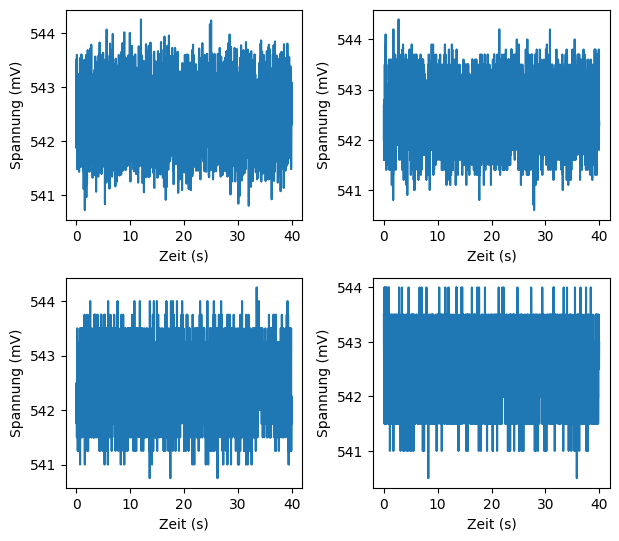

In [3]:
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(16*cm, 14*cm))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

# Die Zeitachse ist jeweils in der ersten Spalte, die gemessene Spannung in der zweiten Spalte.
ax1.plot(data_res1[:, 0], data_res1[:, 1])
ax2.plot(data_res2[:, 0], data_res2[:, 1])
ax3.plot(data_res3[:, 0], data_res3[:, 1])
ax4.plot(data_res4[:, 0], data_res4[:, 1])

# Da alle Plots gleich sind, können wir die Achsenbeschriftungen etc. auch in einer Schleife generieren!
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel('Zeit (s)')
    ax.set_ylabel('Spannung (mV)')
    
fig.tight_layout()

## b)

Bestimmen Sie zu jeder Messung die Auflösung in der Signalgrösse (hier Spannung). Nützliche Funktionen hierfür sind z.B. `np.diff`, `np.sort` und `np.min`.

### Lösung

Die Signalauflösung entspricht der kleinsten Differenz zwischen zwei verschiedenen Messwerten. Wenn wir die Messdaten sortieren, entspricht dies wiederum der kleinsten Differenz zwischen zwei verschiedenen aufeinanderfolgenden Werten. Wir sortieren also zuerst die Daten, nehmen dann die Differenzen, und sortieren diese erneut. Es ist immer hilfreich, so etwas erst einmal zu visualisieren.

In [4]:
# Probieren wir es erst mal mit einem Datensatz
measured_values = data_res1[:, 1]

# Array sortieren
sorted_values = np.sort(measured_values)

# Berechne die Differenzen zwischen aufeinanderfolgenden Werten.
differences = np.diff(sorted_values)

# Absolute Differenzen sortieren, da wir die kleinste Differenz zwischen verschiedenen Messwerten suchen
sorted_differences = np.sort(np.abs(differences))

Text(0, 0.5, 'Differenz (mV)')

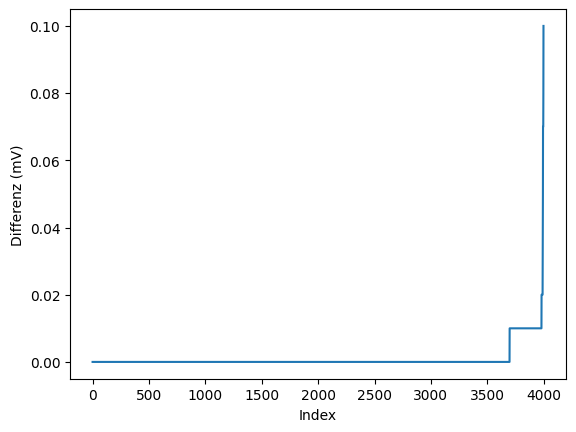

In [5]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(sorted_differences)
ax.set_xlabel('Index')
ax.set_ylabel('Differenz (mV)')

Wir sehen dass die meisten Differenzen beinahe Null sind. Das liegt daran, dass natürlich auch mehrmals der gleiche Wert gemessen werden kann. Wir sind am ersten Wert interessiert, der nicht Null ist. Hier kann man das schon ziemlich gut aus dem Plot ablesen und vermuten, dass die Auflösung 0.01 mV ist. Wir können den Wert auch auslesen:

In [6]:
# Wähle manuell den Index 3800 anhand des Plots aus.
print('Resolution: {:.3f} mV'.format(sorted_differences[3800])) 

Resolution: 0.010 mV


Man könnte das ganze für alle vier Datensätze wiederholen, oder auch eine Funktion schreiben, die das ganze automatisch macht.

In [7]:
def extract_resolution(measured_values):
    '''Extract smallest difference between two unique values in an array.
    Values are treated as unique if their absolute difference is greater than the tolerance.'''
    # Array sortieren
    sorted_values = np.sort(measured_values)
    
    # Berechne die Differenzen zwischen aufeinanderfolgenden Werten.
    differences = np.diff(sorted_values)
    
    # Viele der Differenzen werden (beinahe) Null sein, weil der gleiche Wert mehrmals
    # gemessen worden ist. Wir suchen die kleinste Differenz, die nicht Null ist.
    # Absolute Differenzen sortieren
    sorted_differences = np.sort(np.abs(differences))
    
    # Wir initialisieren die Variable 'resolution' mit einem negativen Wert, damit wir falls etwas\
    # schiefgeht wir eine negative Auflösung bekommen und es merken (z.B. wenn die Toleranz zu gross ist).
    resolution = -1
    
    tolerance = np.max(np.abs(measured_values)) * 1e-10  # Siehe unten für die Erklärung hierzu
    for diff in sorted_differences:
        if diff > tolerance:
            resolution = diff
            break  # for-Schleife unterbrechen
    
    # Das minimum der Differenzen ist die Auflösung
    return resolution


res1 = extract_resolution(data_res1[:, 1])
res2 = extract_resolution(data_res2[:, 1])
res3 = extract_resolution(data_res3[:, 1])
res4 = extract_resolution(data_res4[:, 1])

print('Messung 1: dV = {:.4f} mV'.format(res1))
print('Messung 2: dV = {:.4f} mV'.format(res2))
print('Messung 3: dV = {:.4f} mV'.format(res3))
print('Messung 4: dV = {:.4f} mV'.format(res4))

Messung 1: dV = 0.0100 mV
Messung 2: dV = 0.1000 mV
Messung 3: dV = 0.2500 mV
Messung 4: dV = 0.5000 mV


Um die kleinste Differenz zu finden, die nicht Null ist, ist zu beachten, dass man die Gleichheit von zwei Gleitkommazahlen nicht direkt testen sollte; stattdessen testet man, ob die Differenz kleiner ist als eine gewählte Toleranz. (Mit diesen Daten würde auch ein direkter Vergleich funktionieren, aber nicht im allgemeinen).

Beispiel:

In [8]:
# Zwei Gleitkommazahlen
a = np.exp(1)
b = np.exp(2) / np.exp(1)
# a und b sollten den gleichen Wert haben
print('a = {:f}, b = {:f}'.format(a, b))

# Falscher Vergleich:
print('a == b: {}'.format(a == b))

# Richtiger Vergleich, Toleranz = 1e-6:
tolerance = 1e-6
print('np.abs(a - b) < {:.1e}: {}'.format(tolerance, np.abs(a - b) < tolerance))

a = 2.718282, b = 2.718282
a == b: False
np.abs(a - b) < 1.0e-06: True


Wie gross die Toleranz ist, hängt von den Werten ab, die verglichen werden: Wenn die Toleranz zu gross ist, wird der Vergleich unpräzise. Wenn die Toleranz zu klein ist, stösst man an die Grenzen der Maschinenpräzision und erhält wieder das falsche Resultat (probieren Sie z.B. tolerance = 1e-35 im Beispiel oben).

Für das Beispiel mit den Messdaten wurde die Toleranz relativ zu dem Messwerten gewählt: Zehn Grössenordnungen kleiner als der grösste Messwert. Das ist deswegen sinnvoll, weil durch die Digitalisierung das Verhältnis von grösstem messbaren Wert zur Auflösung limitiert ist (vgl. dynamic range, später in der Vorlesung).

## c)

Plotten Sie nochmal die Daten und beschriften Sie die Plots mit der zugehörigen Signalauflösung. Da die Punkte auf der x-Achse sehr dicht beieinander liegen, lässt sich nicht viel erkennen. Schauen Sie sich deswegen kleinere Bereiche auf der x-Achse an, z.B. 10 Sekunden, 5 Sekunden, 1 Sekunde, 0.1 Sekunden... Können Sie eine Struktur erkennen? Wie wirkt sich die Auflösung aus?

### Lösung

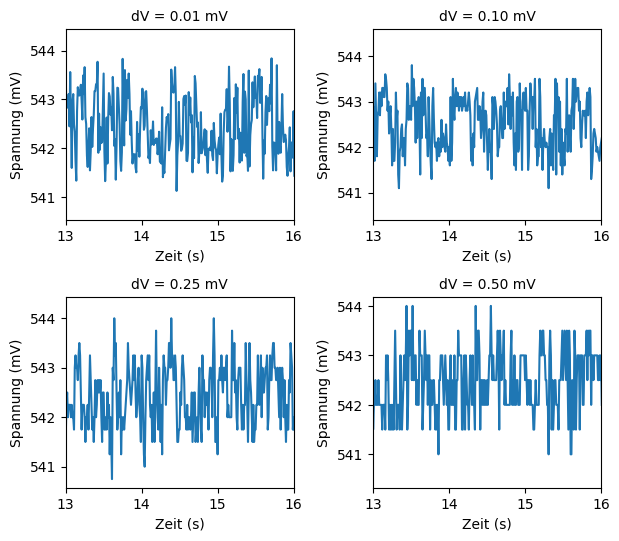

In [9]:
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(16*cm, 14*cm))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

ax1.plot(data_res1[:, 0], data_res1[:, 1])
ax2.plot(data_res2[:, 0], data_res2[:, 1])
ax3.plot(data_res3[:, 0], data_res3[:, 1])
ax4.plot(data_res4[:, 0], data_res4[:, 1])

# Berechnete Auflösungen aus b)
ax1.set_title('dV = {:.2f} mV'.format(res1), size=10)
ax2.set_title('dV = {:.2f} mV'.format(res2), size=10)
ax3.set_title('dV = {:.2f} mV'.format(res3), size=10)
ax4.set_title('dV = {:.2f} mV'.format(res4), size=10)

# Da alle Plots gleich sind, können wir die Achsenbeschriftungen etc. auch in einer Schleife generieren!
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel('Zeit (s)')
    ax.set_ylabel('Spannung (mV)')
    
    # Zoom in der x-Achse
    ax.set_xlim(13, 16)
    
fig.tight_layout()

Wenn man auf einen Bereich von wenigen Sekunden zoomt, kann man schon vermuten, dass die Datenpunkte nicht normalverteilt sind: es zeichnen sich Sprünge zwischen zwei Spannungswerten 542 mV und 543 mV ab. Bei den Auflösungen von 0.25 mV und 0.5 mV kann man dies allerdings nicht mehr erkennen, da die Diskretisierung der Werte durch das Messgerät schon zu grosse Sprünge erzeugt.

## d)

Erstellen Sie ein Histogramm für jede Messung und plotten Sie es. Wählen Sie verschiedene Bingrössen aus, die für kleine oder grosse Signalauflösungen optimiert sind. Was passiert, wenn sie die Bingrösse kleiner als die Auflösung wählen?

Um den Zusammenhang zwischen Signalauflösung und Bingrösse zu veranschaulichen, können Sie immer alle vier Histogramme mit derselben Bingrösse plotten und dann verschiedene Werte für die Bingrösse ausprobieren.

### Lösung

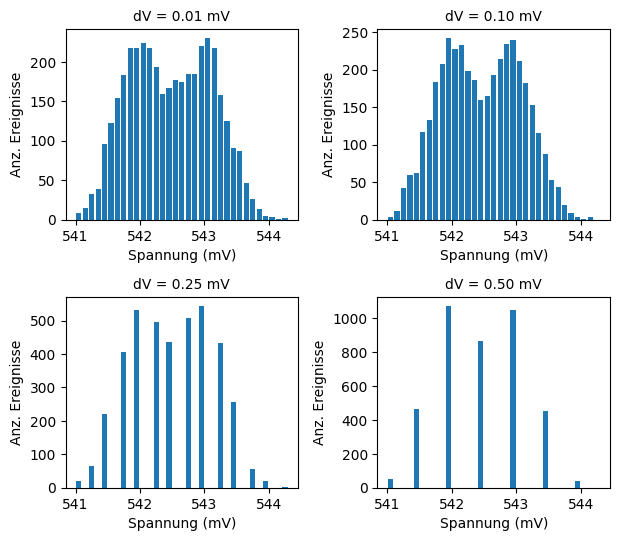

In [10]:
# Wir wählen eine fixe Bingrösse für alle vier Histogramme.
# Verändern Sie diesen Wert um sich zu veranschaulichen, was mit den Histogrammen passiert.
binsize = 0.1

# Histogramme erzeugen
bin_edges = np.arange(541, 544.4, binsize)
bin_centers = bin_edges[:-1] + 0.5 * binsize
hist1, _ = np.histogram(data_res1[:, 1], bins=bin_edges)
hist2, _ = np.histogram(data_res2[:, 1], bins=bin_edges)
hist3, _ = np.histogram(data_res3[:, 1], bins=bin_edges)
hist4, _ = np.histogram(data_res4[:, 1], bins=bin_edges)

# Plots
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(16*cm, 14*cm))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

ax1.bar(bin_centers, hist1, width=binsize*0.8)
ax2.bar(bin_centers, hist2, width=binsize*0.8)
ax3.bar(bin_centers, hist3, width=binsize*0.8)
ax4.bar(bin_centers, hist4, width=binsize*0.8)

ax1.set_title('dV = {:.2f} mV'.format(res1), size=10)
ax2.set_title('dV = {:.2f} mV'.format(res2), size=10)
ax3.set_title('dV = {:.2f} mV'.format(res3), size=10)
ax4.set_title('dV = {:.2f} mV'.format(res4), size=10)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel('Spannung (mV)')
    ax.set_ylabel('Anz. Ereignisse')

fig.tight_layout()

Geeignete Bingrössen sind z.B. 0.05 mV, 0.1 mV, 0.25 mV, 0.5 mV. Man kann folgendes beobachten:

- Wenn die Bingrösse kleiner als die Signalauflösung ist gibt es leere Bins. Insbesondere wenn die Bingrösse ähnlich aber nicht gleich der Signalauflösung ist gibt es merkwürdige Artefakte wie einzelne fehlende Balken im Histogramm (probieren Sie z.B. 0.2 mV als Bingrösse).
- Mit den Auflösungen 0.01 mV und 0.1 mV ist deutlich eine bimodale Verteilung zu sehen (d.h. eine Verteilung mit zwei Maxima). Bei 0.25 mV und 0.5 mV kann man nicht mehr zwischen einer bimodalen Verteilung und einer Normalverteilung mit Rauschen unterscheiden.

## e)

Welche Auflösung würden Sie für diese Messung wählen? Wie hängt die benötigte Auflösung mit den charakteristischen Grössen der Verteilung der Messwerte (z.B. Streuung) zusammen?

### Lösung

Die Auflösung von 0.1 mV ist für diese Messung ausreichend, während 0.25 mV nicht genügt. Mit der noch kleineren Auflösung von 0.01 mV kann man die Messung natürlich auch durchführen, aber man gewinnt dadurch nicht mehr viel Information: Die Auflösung 0.1 mV ist schon kleiner als die Streuung und der Abstand der beiden Moden und reicht damit aus um die Verteilung der Messwerte zu charakterisieren.

# Aufgabe 2: Oszillierendes Signal und Samplingrate

Nun schauen wir uns den Einfluss der Samplingrate, d.h. der zeitlichen Auflösung, auf die Messung von oszillierenden Signalen an. Sie finden die Datensätze zu dieser Aufgabe im Ordner "Aufgabe 2".

## a)

Lesen Sie zuerst den Datensatz 'osc_data_1.txt' ein und bestimmen Sie die Samplingrate. Plotten Sie das Signal als Funktion der Zeit. Verwenden Sie im Plot Marker (z.B. Kreuze oder Punkte), um die Datenpunkte zu markieren.

### Lösung

In [11]:
# Daten einlesen
data1 = np.loadtxt('Aufgabe2/osc_data_1.txt', delimiter=',', comments='#')
time1 = data1[:, 0]
signal1 = data1[:, 1]

# Samplerate: 1 / dt, wobei dt die Zeitdifferenz zwischen zwei Datenpunkten ist.
sample_rate = 1 / (time1[1] - time1[0])

(0.0, 0.1)

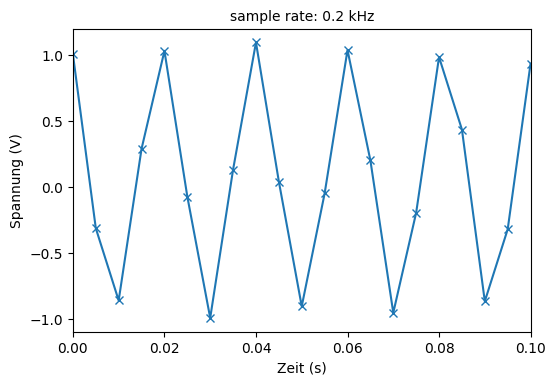

In [12]:
# Daten Potten
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(15*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time1, signal1, 'x-')
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Spannung (V)')
ax.set_title('sample rate: {:.1f} kHz'.format(sample_rate * 1e-3), size=10)

# Wir schauen auf einen kleineren Zeitbereich, um die Oszillation besser zu sehen.
ax.set_xlim(0, 0.1)

## b)

Lesen Sie die Oszillationsfrequenz des Signals aus Ihrem Plot ab.

### Lösung

Aus dem Plot kann man die periode von ca. 0.02 s ablesen -> f = 1 / 0.02s = 50 Hz.

## c)

Lesen Sie nun die Datei 'osc_data_2.txt' ein, bestimmen Sie die Samplingrate, plotten Sie das Signal und bestimmen Sie die Frequenz.

### Lösung

(0.0, 0.1)

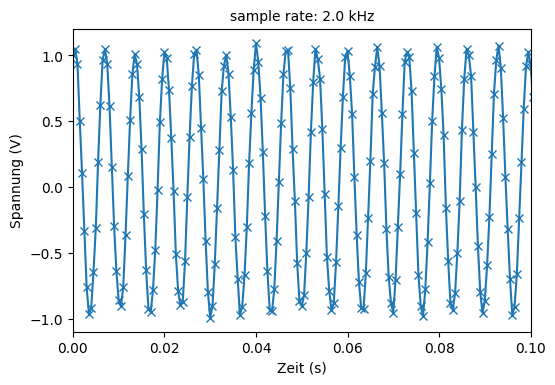

In [13]:
# Daten einlesen
data2 = np.loadtxt('Aufgabe2/osc_data_2.txt', delimiter=',', comments='#')
time2 = data2[:, 0]
signal2 = data2[:, 1]

# Samplerate: 1 / dt, wobei dt die Zeitdifferenz zwischen zwei Datenpunkten ist.
sample_rate2 = 1 / (time2[1] - time2[0])

# Daten Potten

cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(15*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time2, signal2, 'x-')
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Spannung (V)')
ax.set_title('sample rate: {:.1f} kHz'.format(sample_rate2 * 1e-3), size=10)

ax.set_xlim(0, 0.1)
# Zoom zum bestimmen der Frequenz
# ax.set_xlim(0, 0.01)

In [21]:
# Frequenz aus der abgelesenen Periode berechnen
print(1 / 0.0065)

153.84615384615384


Aus dem Plot können wir eine Periode von etwa 6.5 ms ablesen, was einer Frequenz von ca 154 Hz entspricht.

## d)

Plotten Sie beide Datensätze im selbem Plot. Was stellen Sie fest?

### Lösung

(0.0, 0.1)

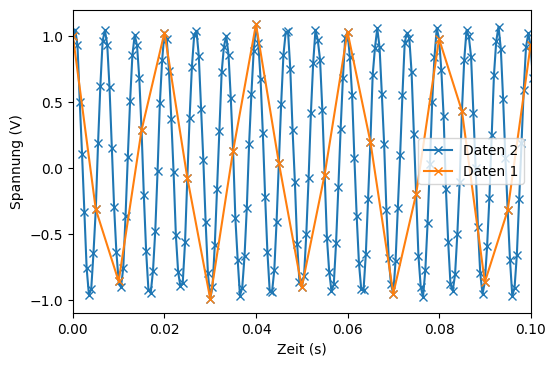

In [14]:
cm = 1 / 2.54  # Zoll zu Centimeter
fig = plt.figure(figsize=(15*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time2, signal2, 'x-', label='Daten 2')
ax.plot(time1, signal1, 'x-', label='Daten 1')
ax.set_xlabel('Zeit (s)')
ax.set_ylabel('Spannung (V)')
ax.legend()

ax.set_xlim(0, 0.1)

Alle Punkte aus dem ersten Datensatz überlappen genau mit Punkten aus dem zweiten Datensatz. Das heisst, wenn die schnelle Oszillation (151.34 Hz) mit der langsamen Samplingrate gemessen wird, kann man sie nicht von einer langsameren Oszillation mit etwa 50 Hz unterschieden. Tatsächlich die überlappenden Punkte hier identisch, weil der Datensatz 1 aus dem Datensatz 2 generiert wurde, indem nur jeder zehnte Punkt verwendet wurde.

Wenn also ein oszillierendes Signal mit einer zu langsamen Samplingrate gemessen wird, ist nicht nur die echte Oszillationsfrequenz nicht messbar, sie erscheint sogar wie eine Oszillation mit langsamerer Frequenz.

## Freiwillige Zusatzaufgabe: Frequenz automatisch bestimmen

In Aufgaben b) und c) haben Sie die ungefähre Frequenz von Auge aus dem Plot abgelesen. Überlegen Sie sich, wie Sie die Frequenz programmatisch aus dem Signal bestimmen könnten, und versuchen Sie Ihren Algorithmus zu implementieren.

Da wir erst später in der Vorlesung genauer auf die Analyse die Analyse von oszillierenden Signalen zu sprechen kommen, brauchen Sie sich keine Gedanken zu machen, wenn Sie diese Aufgabe nicht bearbeiten möchten.

### Lösung

In [15]:
# Hier eine Implementation eines einfachen Algorithmus zur Bestimmung der Frequenz mit den Mitteln,
# die Sie in dieser Vorlesung bereits kennengelernt haben. Diese Methode ist nicht besonders robust und
# versagt, wenn es Rauschen auf den Daten gibt.
def get_frequency(time, signal):
    '''Find frequency of an oscillatory signal by calculating the mean distance between local maxima
    in the signal.'''
    n_points = len(time)

    period_sum = 0  # Speichert die Summe der Perioden
    n_period = 0  # Speichert die Anzahl der berechneten Perioden für das Mitteln: period = period_sum / n_period
    prev_max_index = 0  # Speichert den Index des letzten Maximums.
    
    # Als erstes suchen wir das erste lokale Maximum im Signal.
    for i in range(1, n_points-2):
        if signal[i-1] < signal[i] and signal[i+1] < signal[i]:
            prev_max_index = i
            break
    
    # In einer for-Schleife iterieren wir vom ersten Punkt nach dem ersten Maximum bis zum vorletzten Punkt,
    # weil wir jeden Punkt mit seinen Nachbarpunkten vergleichen wollen.
    for i in range(prev_max_index+1, n_points-2):
        # Wir suchen lokale maxima, d.h. Punkte, die grösser sind als beide Nachbarpunkte.
        if signal[i-1] < signal[i] and signal[i+1] < signal[i]:
            # Wenn wir ein Maximum finden, addieren wir die Zeitdifferenz zum letzten Maximum
            # zu der period_sum variable, und erhöhen die Anzahl der addierten Zeitdifferenzen um eins.
            period_sum += time[i] - time[prev_max_index]
            n_period += 1
            
            # Ausserdem müssen wir den Index zum letzten Maximum updaten.
            prev_max_index = i
    
    
    # Mittelwert berechnen und Frequenz zurückgeben.
    period = period_sum / n_period
    return 1 / period


print('Frequenz 1: {:.2f} Hz'.format(get_frequency(time1, signal1)))
print('Frequenz 2: {:.2f} Hz'.format(get_frequency(time2, signal2)))

Frequenz 1: 48.89 Hz
Frequenz 2: 151.36 Hz


In [16]:
# Eine andere Möglichkeit basierend auf der gleichen Idee wäre, die Funktion argrelmax aus der
# Bibliothek scipy.signal zu verwenden. Diese Funktion findet die Indizes aller lokalen Maxima eines Arrays.
# Die Funktion hat das Argument 'order', was angibt, wieviele Punkte in der Nachbarschaft beim bestimmen
# der lokalen Maxima berücksichtigt werden, was den Algorithmus ein bisschen stabiler gegen Rauschen macht.
import scipy.signal

def get_frequency_scipy(time, signal):
    '''Find frequency of an oscillatory signal by calculating the mean distance between local maxima
    in the signal using scipy.signal.argrelmax'''
    max_indices = scipy.signal.argrelmax(signal, order=3)[0]
    n_period = len(max_indices) - 1
    period_sum = 0
    
    for i in range(0, n_period):
        period_sum += time[max_indices[i+1]] - time[max_indices[i]]
        
    period = period_sum / n_period
    return 1 / period


print('Frequenz 1: {:.2f} Hz'.format(get_frequency_scipy(time1, signal1)))
print('Frequenz 2: {:.2f} Hz'.format(get_frequency_scipy(time2, signal2)))

Frequenz 1: 48.94 Hz
Frequenz 2: 151.36 Hz


Eine bessere Methode, die auch mit verrauschten Daten funktioniert, beruht auf Fouriertransformation. Sie werden diese später in der Vorlesung kennenlernen.